# Full pipeline walkthrough (Tasks 1-5)

One section per task, each run against real data, showing what that stage of the
pipeline actually produces. See `PREPROCESSING_PLAN.md` for the design history and
`notebooks/03_task2_sem_band_detection_investigation.ipynb` for the SEM band-detection
debugging session behind Task 2.

In [ ]:
import sys
import json
import pickle
from pathlib import Path

# Auto-detect repo root: search upward from cwd for pyproject.toml -- robust to
# whatever directory Jupyter was launched from (local VS Code, remote Linux server, etc.)
def _find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    return p  # fallback: no marker found, use cwd as-is

REPO = _find_repo_root()
sys.path.insert(0, str(REPO / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import preprocessing as p
from nsf_fmrg_data import load_wyko_asc, robust_plane_detrend, load_sem_tile

THERMAL_DIR = REPO / 'data' / 'raw' / 'thermal'
SEM_DIR = REPO / 'data' / 'raw' / 'sem'
HEIGHT_DIR = REPO / 'data' / 'raw' / 'height_maps'
plt.rcParams['figure.dpi'] = 100

TRACK_ID = 8  # used as the running example for tasks 1, 2, 4

## Task 1 — height-map target extraction

`Z_mm` is plane-detrended (see the tilt-vs-texture discussion in `PREPROCESSING_PLAN.md`
Task 4), then `extract_local_width_stats` walks the track at 0.2mm steps, detecting the
track's left/right boundary per column and aggregating into width/roughness stats per
window.

377/389 windows valid, median width = 0.409 mm


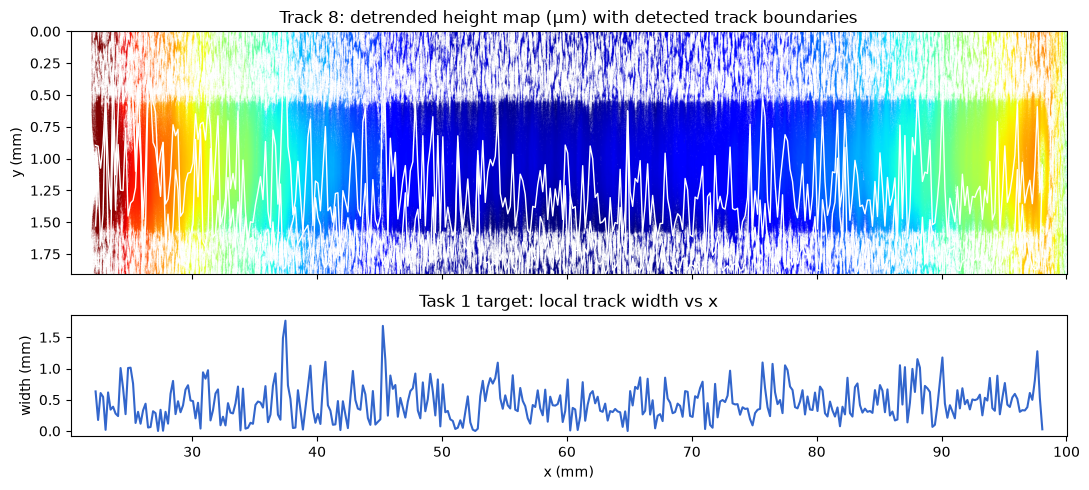

In [ ]:
height = load_wyko_asc(HEIGHT_DIR, TRACK_ID, crop_to_common=True)
Z_detrended, _ = robust_plane_detrend(height['Z_mm'], height['x_actual_mm'], height['y_mm'])
x_mm = height['x_actual_mm']
y_mm = height['y_mm']

x_centers = np.arange(x_mm.min() + 1, x_mm.max() - 1, 0.2)
stats = p.extract_local_width_stats(Z_detrended, x_mm, y_mm, x_centers, window_mm=p.THERMAL_MM_PER_FRAME)
valid = stats['valid']

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
axes[0].imshow(Z_detrended * 1000, cmap='jet', aspect='auto',
               extent=[x_mm[0], x_mm[-1], y_mm[-1], y_mm[0]], vmin=-50, vmax=125)
axes[0].plot(stats['x_mm'][valid], stats['boundary_left_mean_mm'][valid], color='white', lw=1)
axes[0].plot(stats['x_mm'][valid], stats['boundary_right_mean_mm'][valid], color='white', lw=1)
axes[0].set_ylabel('y (mm)')
axes[0].set_title(f'Track {TRACK_ID}: detrended height map (\xb5m) with detected track boundaries')

axes[1].plot(stats['x_mm'][valid], stats['width_mean_mm'][valid], color='#3366cc')
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('width (mm)')
axes[1].set_title('Task 1 target: local track width vs x')
plt.tight_layout()
plt.show()

print(f"{valid.sum()}/{len(stats)} windows valid, median width = {np.nanmedian(stats['width_mean_mm'][valid]):.3f} mm")

## Task 2 — SEM anti-leakage crop + tile mapping

`detect_track_row_band` finds the track's row extent in a SEM tile (three gates:
relative roughness threshold, windowed density, peak-density solid-core check — see
notebook 03 for why each was needed). `crop_sem_context` then returns everything
*outside* the band (+ safety margin) as usable context — the band itself is excluded so
the model can't just read the answer off the SEM image.

band valid: True, band rows: 281..438
context shapes: top=(266, 1024), bottom=(315, 1024)


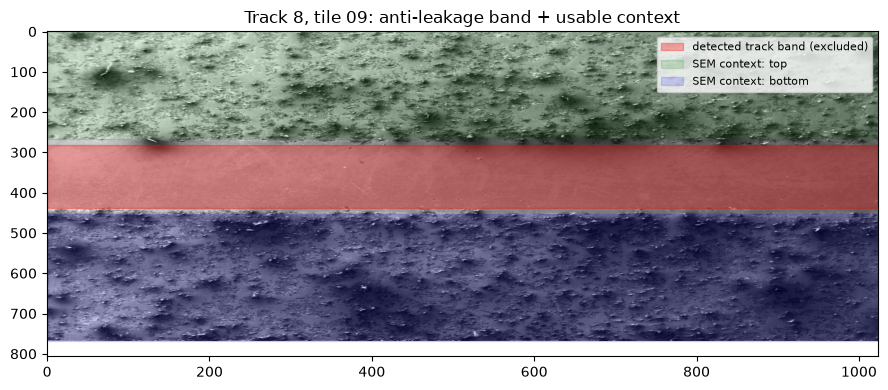

In [ ]:
tile_idx = 9
tile_paths = p.sem_tile_paths(SEM_DIR, TRACK_ID)
img = load_sem_tile(tile_paths[tile_idx - 1])
row_start, row_stop, band_valid = p.detect_track_row_band(img)
ctx = p.crop_sem_context(img, row_start, row_stop)
top_edge = max(0, row_start - p.SEM_BAND_MARGIN_PX)
bottom_edge = min(img.shape[0], row_stop + p.SEM_BAND_MARGIN_PX)

fig, ax = plt.subplots(figsize=(9, 4))
ax.imshow(img, cmap='gray', aspect='auto')
ax.axhspan(row_start, row_stop, color='red', alpha=0.3, label='detected track band (excluded)')
ax.axhspan(0, top_edge, color='green', alpha=0.15, label='SEM context: top')
ax.axhspan(bottom_edge, img.shape[0], color='blue', alpha=0.15, label='SEM context: bottom')
ax.set_title(f'Track {TRACK_ID}, tile {tile_idx:02d}: anti-leakage band + usable context')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print(f'band valid: {band_valid}, band rows: {row_start}..{row_stop}')
print(f"context shapes: top={ctx['top'].shape}, bottom={ctx['bottom'].shape}")

## Task 3 — leave-one-track-out CV splits

Track 21 is the fixed held-out test set (worst height-map NaN coverage, per the paper's
own recommendation). Development/tuning cross-validates over tracks 8, 10, 14 only.

In [ ]:
for train_tracks, val_track in p.loto_cv_splits():
    print(f'train={train_tracks}  val={val_track}')
print(f'held-out test track (never in CV): {p.HELD_OUT_TEST_TRACK}')

train=(10, 14)  val=8
train=(8, 14)  val=10
train=(8, 10)  val=14
held-out test track (never in CV): 21


## Task 4 — one assembled sample

`build_track_samples` pairs, for one thermal frame: the `\xb1k` thermal window, the
resolved (anti-leakage) SEM context for that frame's physical x, and the Task-1 target
stats at that exact x. This is what one row of the final dataset actually looks like.

target stats for this sample:
  valid: True
  nan_frac: 0.2977941176470588
  width_mean_mm: 0.3356257142857143
  width_std_mm: 0.3382354444181974
  boundary_left_mean_mm: 1.4453237857142862
  boundary_right_mean_mm: 1.7809495
  edge_roughness_mm: 0.33833759289942644


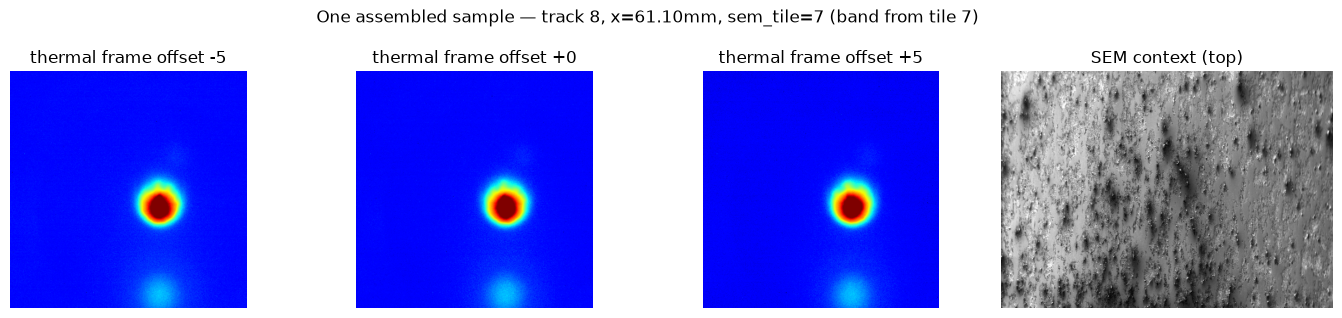

In [ ]:
rows = p.build_track_samples(TRACK_ID, THERMAL_DIR, SEM_DIR, HEIGHT_DIR, k=5)
sample = rows[200]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, offset in zip(axes[:3], [-5, 0, 5]):
    ax.imshow(sample['thermal_window'][offset + 5], cmap='jet', vmin=1000, vmax=2500)
    ax.set_title(f'thermal frame offset {offset:+d}')
    ax.axis('off')
axes[3].imshow(sample['sem_context_top'], cmap='gray', aspect='auto')
axes[3].set_title('SEM context (top)')
axes[3].axis('off')
plt.suptitle(f"One assembled sample \u2014 track {sample['track_id']}, x={sample['x_mm']:.2f}mm, "
             f"sem_tile={sample['sem_tile_index']} (band from tile {sample['sem_band_source_tile']})")
plt.tight_layout()
plt.show()

print('target stats for this sample:')
for key in ['valid', 'nan_frac', 'width_mean_mm', 'width_std_mm',
            'boundary_left_mean_mm', 'boundary_right_mean_mm', 'edge_roughness_mm']:
    print(f'  {key}: {sample[key]}')

## Task 5 — the assembled processed dataset

Loading the actual output of `scripts/build_processed_dataset.py`'s most recent run
(not re-running it here — that run already wrote ~11GB to `processed_data/datasets/`).

In [ ]:
run_dirs = sorted((REPO / 'processed_data' / 'datasets').iterdir())
run_dir = run_dirs[-1]
with open(run_dir / 'provenance.json') as f:
    provenance = json.load(f)
provenance

{'run_tag': '20260715_145326', 'commit_hash': 'c392dce2f651170e6a484fe89c28a135322bbe1b', 'git_dirty': True, 'data_hash': {'thermal.zip': '05488497004e38c3e805d61cc6e4bd08', 'sem.zip': '5ad0ec6d5f9d4566b7e02a3820681b30', 'height_maps.zip': 'b97c87ae236dc7316d37dcd89d19e413'}, 'k': 5, 'tracks': {'8': {'n_samples': 390, 'n_valid': 375}, '10': {'n_samples': 390, 'n_valid': 350}, '14': {'n_samples': 390, 'n_valid': 363}, '21': {'n_samples': 390, 'n_valid': 336}}}

In [ ]:
summary_rows = []
for track_id in [8, 10, 14, 21]:
    with open(run_dir / f'track_{track_id}_samples.pkl', 'rb') as f:
        track_rows = pickle.load(f)
    n_valid = sum(r['valid'] for r in track_rows)
    n_fallback = sum(r['sem_band_source_tile'] != r['sem_tile_index'] for r in track_rows)
    summary_rows.append(dict(track=track_id, n_samples=len(track_rows), n_valid=n_valid, n_fallback=n_fallback))

summary = pd.DataFrame(summary_rows)
summary

,track,n_samples,n_valid,n_fallback
0,8,390,375,87
1,10,390,350,87
2,14,390,363,26
3,21,390,336,24


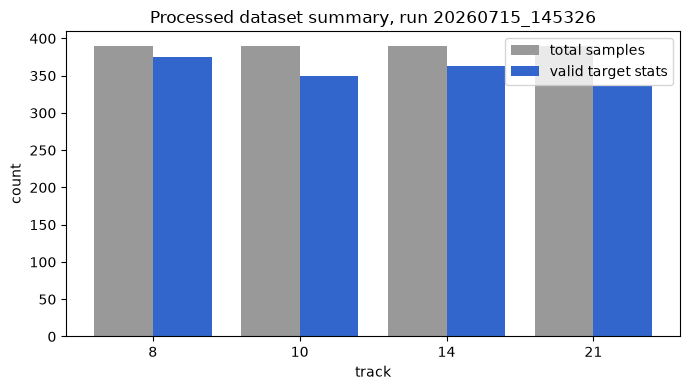

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(summary))
ax.bar(x - 0.2, summary['n_samples'], width=0.4, label='total samples', color='#999999')
ax.bar(x + 0.2, summary['n_valid'], width=0.4, label='valid target stats', color='#3366cc')
ax.set_xticks(x)
ax.set_xticklabels(summary['track'])
ax.set_xlabel('track')
ax.set_ylabel('count')
ax.set_title(f'Processed dataset summary, run {run_dir.name}')
ax.legend()
plt.tight_layout()
plt.show()

## Status

All 5 preprocessing tasks are implemented and this run's provenance is pinned above.
Still open (see `PREPROCESSING_PLAN.md`): a *clean* (committed, non-dirty) decision-grade
run; the Task-1 near-zero-width hardening caveat; why track 21's SEM band heights run
narrower in pixels than tracks 8/10/14 despite having the widest height-map track.